# RQ1 Clean Comparison: TF-IDF + Logistic Regression vs DistilBERT
This notebook provides a clean and fair comparison pipeline for:
1. **Baseline:** TF-IDF + Logistic Regression
2. **Deep Learning model:** DistilBERT

Both models use the same training/validation split from the balanced dataset and are tested on the same random real-world dataset.

## Why this version is cleaner
- Uses **TF-IDF + Logistic Regression** exactly as the baseline in the proposal.
- Removes `class_weight='balanced'` from Logistic Regression because the training set is already balanced.
- Uses one shared evaluation function for both models.
- Produces a single comparison table with accuracy, precision, recall, and F1.

In [ ]:

# Install packages if needed
!pip install -q transformers datasets accelerate scikit-learn


In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)


In [ ]:

# Update these paths if needed
balanced_path = "/content/sample_data/cleaned_amazon_balanced_reviews.csv"
random_path = "/content/sample_data/cleaned_amazon_random_reviews.csv"

df_bal = pd.read_csv(balanced_path)
df_rand = pd.read_csv(random_path)

#Keep only needed columns
required_cols = ["clean_text_final", "sentiment"]
df_bal = df_bal.dropna(subset=required_cols).copy()
df_rand = df_rand.dropna(subset=required_cols).copy()

df_bal["clean_text_final"] = df_bal["clean_text_final"].astype(str)
df_rand["clean_text_final"] = df_rand["clean_text_final"].astype(str)

print("Balanced dataset shape:", df_bal.shape)
print("Random dataset shape:", df_rand.shape)
print("\nBalanced sentiment counts:")
print(df_bal["sentiment"].value_counts().sort_index())
print("\nRandom sentiment counts:")
print(df_rand["sentiment"].value_counts().sort_index())


Balanced dataset shape: (49688, 15)
Random dataset shape: (46352, 16)

Balanced sentiment counts:
sentiment
0    14946
1    14864
2    19878
Name: count, dtype: int64

Random sentiment counts:
sentiment
0     6868
1     3235
2    36249
Name: count, dtype: int64


In [ ]:

# Same split used for both models
X = df_bal["clean_text_final"]
y = df_bal["sentiment"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_test = df_rand["clean_text_final"]
y_test = df_rand["sentiment"]

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Random test size:", len(X_test))


Train size: 39750
Validation size: 9938
Random test size: 46352


In [ ]:

# Shared helper functions
label_order = sorted(df_bal["sentiment"].unique().tolist())

def evaluate_predictions(y_true, y_pred, model_name, dataset_name):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "Model": model_name,
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_weighted": precision,
        "Recall_weighted": recall,
        "F1_weighted": f1
    }

def print_report(y_true, y_pred, title):
    print(f"=== {title} ===")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print(classification_report(y_true, y_pred, digits=4))

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=label_order)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_order,
        yticklabels=label_order
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


## Part A. Baseline: TF-IDF + Logistic Regression

In [ ]:

# Clean baseline pipeline
tfidf_lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=30000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

tfidf_lr_pipeline.fit(X_train, y_train)

lr_val_preds = tfidf_lr_pipeline.predict(X_val)
lr_test_preds = tfidf_lr_pipeline.predict(X_test)

print_report(y_val, lr_val_preds, "TF-IDF + Logistic Regression | Balanced Validation")
print_report(y_test, lr_test_preds, "TF-IDF + Logistic Regression | Random Test")


=== TF-IDF + Logistic Regression | Balanced Validation ===
Accuracy: 0.686
              precision    recall  f1-score   support

           0     0.6766    0.6852    0.6809      2989
           1     0.5549    0.4998    0.5259      2973
           2     0.7756    0.8257    0.7999      3976

    accuracy                         0.6860      9938
   macro avg     0.6690    0.6702    0.6689      9938
weighted avg     0.6798    0.6860    0.6821      9938

=== TF-IDF + Logistic Regression | Random Test ===
Accuracy: 0.7658
              precision    recall  f1-score   support

           0     0.5989    0.7117    0.6504      6868
           1     0.2046    0.5023    0.2908      3235
           2     0.9582    0.7996    0.8718     36249

    accuracy                         0.7658     46352
   macro avg     0.5872    0.6712    0.6043     46352
weighted avg     0.8524    0.7658    0.7984     46352



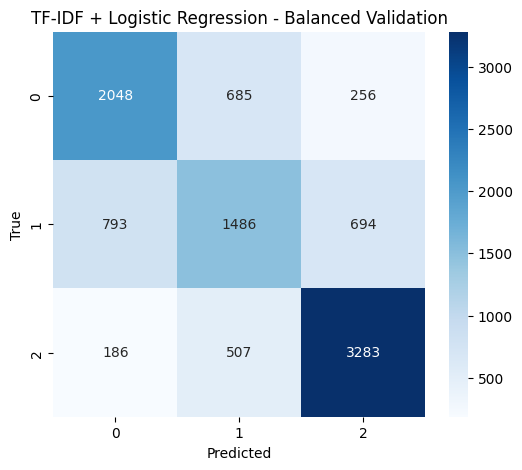

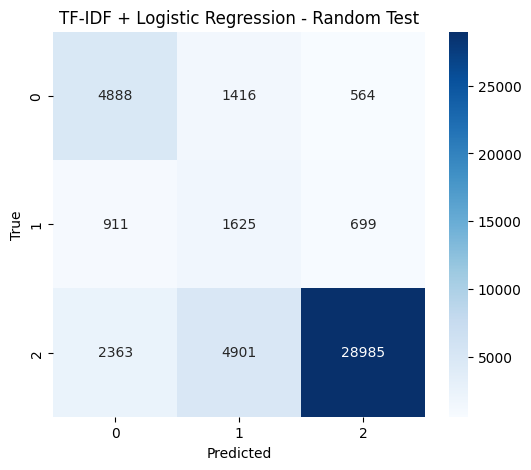

In [ ]:

plot_conf_matrix(y_val, lr_val_preds, "TF-IDF + Logistic Regression - Balanced Validation")
plot_conf_matrix(y_test, lr_test_preds, "TF-IDF + Logistic Regression - Random Test")


The TF-IDF + Logistic Regression model achieved 68.6% accuracy on a balanced validation set and 76.6% on a random test set. However, the higher accuracy on the random test is influenced by class imbalance, where the model favors the dominant positive class. The model performs well in identifying positive reviews but struggles significantly with neutral sentiment, indicating limitations of TF-IDF features in capturing nuanced semantic differences

## Part B. DistilBERT

In [ ]:

# Convert pandas splits into Hugging Face datasets
train_df = pd.DataFrame({"text": X_train.tolist(), "label": y_train.tolist()})
val_df = pd.DataFrame({"text": X_val.tolist(), "label": y_val.tolist()})
test_df = pd.DataFrame({"text": X_test.tolist(), "label": y_test.tolist()})

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)


In [ ]:

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_ds = train_ds.map(tokenize_function, batched=True)
val_ds = val_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)

keep_cols = ["input_ids", "attention_mask", "label"]
train_ds = train_ds.remove_columns([c for c in train_ds.column_names if c not in keep_cols])
val_ds = val_ds.remove_columns([c for c in val_ds.column_names if c not in keep_cols])
test_ds = test_ds.remove_columns([c for c in test_ds.column_names if c not in keep_cols])

train_ds.set_format("torch")
val_ds.set_format("torch")
test_ds.set_format("torch")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/39750 [00:00<?, ? examples/s]

Map:   0%|          | 0/9938 [00:00<?, ? examples/s]

Map:   0%|          | 0/46352 [00:00<?, ? examples/s]

In [ ]:

distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_order)
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1
    }


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:

training_args = TrainingArguments(
    output_dir="./distilbert_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    report_to="none"
)

trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)


In [ ]:

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted
1,0.760481,0.720361,0.673476,0.672137,0.673476,0.664397
2,0.610798,0.714727,0.699738,0.701595,0.699738,0.700607


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=9938, training_loss=0.6856393919645553, metrics={'train_runtime': 1988.1456, 'train_samples_per_second': 39.987, 'train_steps_per_second': 4.999, 'total_flos': 5265673000704000.0, 'train_loss': 0.6856393919645553, 'epoch': 2.0})

In [ ]:

# Predictions for the same validation and test sets used by the baseline
val_outputs = trainer.predict(val_ds)
bert_val_preds = np.argmax(val_outputs.predictions, axis=1)

test_outputs = trainer.predict(test_ds)
bert_test_preds = np.argmax(test_outputs.predictions, axis=1)

print_report(y_val, bert_val_preds, "DistilBERT | Balanced Validation")
print_report(y_test, bert_test_preds, "DistilBERT | Random Test")


=== DistilBERT | Balanced Validation ===
Accuracy: 0.6997
              precision    recall  f1-score   support

           0     0.6945    0.6852    0.6898      2989
           1     0.5566    0.5735    0.5649      2973
           2     0.8153    0.8051    0.8102      3976

    accuracy                         0.6997      9938
   macro avg     0.6888    0.6879    0.6883      9938
weighted avg     0.7016    0.6997    0.7006      9938

=== DistilBERT | Random Test ===
Accuracy: 0.7577
              precision    recall  f1-score   support

           0     0.6429    0.7181    0.6785      6868
           1     0.1886    0.5413    0.2797      3235
           2     0.9675    0.7846    0.8665     36249

    accuracy                         0.7577     46352
   macro avg     0.5997    0.6813    0.6082     46352
weighted avg     0.8650    0.7577    0.7977     46352



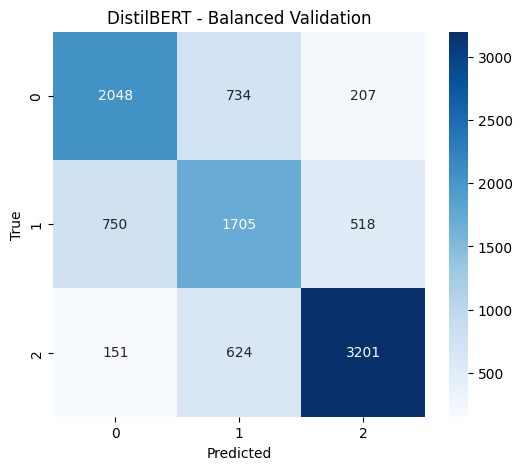

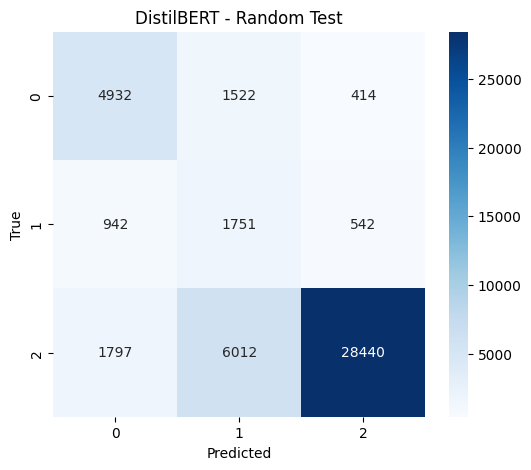

In [ ]:

plot_conf_matrix(y_val, bert_val_preds, "DistilBERT - Balanced Validation")
plot_conf_matrix(y_test, bert_test_preds, "DistilBERT - Random Test")


## Final Comparison Table

In [ ]:

results = []
results.append(evaluate_predictions(y_val, lr_val_preds, "TF-IDF + Logistic Regression", "Balanced Validation"))
results.append(evaluate_predictions(y_test, lr_test_preds, "TF-IDF + Logistic Regression", "Random Test"))
results.append(evaluate_predictions(y_val, bert_val_preds, "DistilBERT", "Balanced Validation"))
results.append(evaluate_predictions(y_test, bert_test_preds, "DistilBERT", "Random Test"))

results_df = pd.DataFrame(results)
results_df


,Model,Dataset,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
0,TF-IDF + Logistic Regression,Balanced Validation,0.685953,0.679781,0.685953,0.682115
1,TF-IDF + Logistic Regression,Random Test,0.765835,0.852399,0.765835,0.798424
2,DistilBERT,Balanced Validation,0.699738,0.701595,0.699738,0.700607
3,DistilBERT,Random Test,0.757745,0.865031,0.757745,0.797667


- Balanced validation provides a fair comparison across all sentiment classes by removing class imbalance effects
- DistilBERT outperforms TF-IDF + Logistic Regression on this dataset, showing improved accuracy (0.686 → 0.700) and F1-score (0.682 → 0.701)
- Random test data reflects real-world distribution, where positive reviews dominate
- On the random test set, both models perform similarly (~0.76 accuracy, ~0.80 F1) due to class imbalance.

**Key Insights**
- DistilBERT advantage:

Better captures contextual meaning than TF-IDF

Leads to improved performance in balanced evaluation

- Neutral class remains challenging:

Both models struggle to correctly classify neutral reviews

Indicates ambiguity and mixed sentiment in neutral text

- Impact of class imbalance:

Inflates accuracy in random test results

Causes bias toward the dominant positive class

- Evaluation takeaway:

Balanced data → true model capability

Random data → real-world behavior and limitation

**DistilBERT provides modest but consistent improvement over the TF-IDF baseline, but both models remain limited in handling neutral sentiment, especially under real-world class imbalance**

In [ ]:

comparison_pivot = results_df.pivot(index="Dataset", columns="Model", values=["Accuracy", "F1_weighted"])
comparison_pivot


Accuracy                              F1_weighted  \
Model               DistilBERT TF-IDF + Logistic Regression  DistilBERT   
Dataset                                                                   
Balanced Validation   0.699738                     0.685953    0.700607   
Random Test           0.757745                     0.765835    0.797667   

                                                  
Model               TF-IDF + Logistic Regression  
Dataset                                           
Balanced Validation                     0.682115  
Random Test                             0.798424

The pivot table provides a side-by-side comparison of model performance across datasets and evaluation metrics. It shows that DistilBERT outperforms TF-IDF + Logistic Regression on the balanced validation set in both accuracy and F1-score. However, on the random test set, both models achieve nearly identical performance, indicating that class imbalance limits the practical advantage of DistilBER

In [ ]:

# Optional: compute improvement of DistilBERT over TF-IDF + LR
pivot_acc = results_df.pivot(index="Dataset", columns="Model", values="Accuracy")
pivot_f1 = results_df.pivot(index="Dataset", columns="Model", values="F1_weighted")

improvement_df = pd.DataFrame({
    "Accuracy_Improvement": pivot_acc["DistilBERT"] - pivot_acc["TF-IDF + Logistic Regression"],
    "F1_Improvement": pivot_f1["DistilBERT"] - pivot_f1["TF-IDF + Logistic Regression"]
}).reset_index()

improvement_df


,Dataset,Accuracy_Improvement,F1_Improvement
0,Balanced Validation,0.013785,0.018492
1,Random Test,-0.008090,-0.000757


**1. DistilBERT outperforms TF-IDF + Logistic Regression on the balanced validation set**
*   +1.38% accuracy improvement
*   +1.85% F1-score improvement

**2. This shows a modest but consistent advantage of DistilBERT under fair (balanced) condition**

**3. On the imbalanced random test set, DistilBERT shows a slight performance decrease**

**4. This indicates that class imbalance reduces the practical advantage of transformer models, especially when positive reviews dominat**

## Suggested interpretation
- **Use TF-IDF + Logistic Regression as the baseline**, because it matches the proposal and is the standard traditional NLP baseline.
- **Use DistilBERT as the deep learning model**, because it captures contextual meaning beyond bag-of-words features.
- Report both **validation** and **random test** results.
- If DistilBERT shows only a small gain, that is still valid; explain that the gain may be limited by dataset size, review ambiguity, and the difficulty of the neutral class.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "/content"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)



Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
model.save_pretrained("/content/distilbert_final_v1")
tokenizer.save_pretrained("/content/distilbert_final_v1")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/distilbert_final_v1/tokenizer_config.json',
 '/content/distilbert_final_v1/tokenizer.json')

In [ ]:
import shutil
shutil.make_archive('distilbert_final_v1', 'zip', '/content/distilbert_final_v1')

'/content/distilbert_final_v1.zip'

In [ ]:
from google.colab import files
files.download('distilbert_final_v1.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>